# 🏦 Predicción de Churn de Clientes Bancarios con PySpark

En este notebook construiremos un pipeline de Machine Learning para predecir la fuga de clientes (*churn*) en un banco, utilizando PySpark. El flujo sigue buenas prácticas de ingeniería de datos y aprendizaje automático, e incluye exploración, preparación, modelado y evaluación.

---

## 1️⃣ Configuración e importación de librerías

En primer lugar, configuramos el entorno y cargamos las librerías necesarias.

In [40]:
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"

from pyspark.sql import SparkSession
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.sql.functions import when
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve

## 2️⃣ Creación de la SparkSession

La SparkSession es el punto de entrada para trabajar con DataFrames y ML en PySpark.

In [41]:
spark = SparkSession.builder.appName("PrediccionChurn").getOrCreate()

## 3️⃣ Carga y exploración de los datos

Leemos el dataset y realizamos una inspección inicial para conocer su estructura y contenido.

In [23]:
file_path = "data/Bank_Customer_Churn_Prediction.csv"
df = spark.read.csv(file_path, header=True, inferSchema=True)
df.show(5)
df.printSchema()
df.groupBy("churn").count().show()

+-----------+------------+-------+------+---+------+---------+---------------+-----------+-------------+----------------+-----+
|customer_id|credit_score|country|gender|age|tenure|  balance|products_number|credit_card|active_member|estimated_salary|churn|
+-----------+------------+-------+------+---+------+---------+---------------+-----------+-------------+----------------+-----+
|   15634602|         619| France|Female| 42|     2|      0.0|              1|          1|            1|       101348.88|    1|
|   15647311|         608|  Spain|Female| 41|     1| 83807.86|              1|          0|            1|       112542.58|    0|
|   15619304|         502| France|Female| 42|     8| 159660.8|              3|          1|            0|       113931.57|    1|
|   15701354|         699| France|Female| 39|     1|      0.0|              2|          0|            0|        93826.63|    0|
|   15737888|         850|  Spain|Female| 43|     2|125510.82|              1|          1|            1|

## 4️⃣ Limpieza y preparación de los datos

Filtramos los datos para quedarnos solo con los registros válidos y preparamos las variables categóricas y numéricas.

In [42]:
# Filtrar solo filas con churn 0 o 1 y sin nulos en categóricas
df = df.filter((df.churn == 0) | (df.churn == 1))
cat_cols = ["country", "gender"]  
for c in cat_cols:
    df = df.filter(df[c].isNotNull())

# Variables numéricas (incluye las binarias)
num_cols = [
    "credit_score", "age", "tenure", "balance",
    "products_number", "estimated_salary", "credit_card", "active_member"
]

## 5️⃣ Ingeniería de variables: indexado y codificación

Convertimos las variables categóricas a formato numérico usando `StringIndexer` y `OneHotEncoder`, y ensamblamos todas las variables en un único vector de características.

In [25]:
# Indexar y codificar variables categóricas
indexers = [StringIndexer(inputCol=c, outputCol=c+"_idx", handleInvalid="keep") for c in cat_cols]
encoders = [OneHotEncoder(inputCol=c+"_idx", outputCol=c+"_ohe") for c in cat_cols]

# Vector de features
feature_cols = [c+"_ohe" for c in cat_cols] + num_cols
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")

In [43]:
# Aplicar indexers y encoders a un pequeño subset para visualizar
sample = df.limit(10)

# Solo indexers y encoders
pipeline_vis = Pipeline(stages=indexers + encoders)
model_vis = pipeline_vis.fit(sample)
df_encoded = model_vis.transform(sample)

# Mostrar las columnas originales, indexadas y codificadas
df_encoded.select(cat_cols + [c+"_idx" for c in cat_cols] + [c+"_ohe" for c in cat_cols]).show(truncate=False)

+-------+------+-----------+----------+-------------+-------------+
|country|gender|country_idx|gender_idx|country_ohe  |gender_ohe   |
+-------+------+-----------+----------+-------------+-------------+
|France |Female|0.0        |0.0       |(3,[0],[1.0])|(2,[0],[1.0])|
|Spain  |Female|1.0        |0.0       |(3,[1],[1.0])|(2,[0],[1.0])|
|France |Female|0.0        |0.0       |(3,[0],[1.0])|(2,[0],[1.0])|
|France |Female|0.0        |0.0       |(3,[0],[1.0])|(2,[0],[1.0])|
|Spain  |Female|1.0        |0.0       |(3,[1],[1.0])|(2,[0],[1.0])|
|Spain  |Male  |1.0        |1.0       |(3,[1],[1.0])|(2,[1],[1.0])|
|France |Male  |0.0        |1.0       |(3,[0],[1.0])|(2,[1],[1.0])|
|Germany|Female|2.0        |0.0       |(3,[2],[1.0])|(2,[0],[1.0])|
|France |Male  |0.0        |1.0       |(3,[0],[1.0])|(2,[1],[1.0])|
|France |Male  |0.0        |1.0       |(3,[0],[1.0])|(2,[1],[1.0])|
+-------+------+-----------+----------+-------------+-------------+



## 6️⃣ Definición del modelo y pipeline

Utilizamos regresión logística para la predicción y organizamos todo el flujo en un pipeline.

In [ ]:
# Modelo (la variable a predecir es churn, que ya es 0/1)
lr = LogisticRegression(featuresCol="features", labelCol="churn")

# Construcción del pipeline de Machine Learning:
# 1. Los indexers convierten las variables categóricas de texto a índices numéricos.
# 2. Los encoders transforman esos índices en vectores one-hot (columnas binarias).
# 3. El assembler une todas las variables numéricas y codificadas en un solo vector de features.
# 4. Finalmente, se agrega el modelo de regresión logística que usará ese vector para predecir churn.
stages = indexers + encoders + [assembler, lr]
pipeline = Pipeline(stages=stages)

## 7️⃣ División en entrenamiento y test

Dividimos los datos para evaluar el desempeño del modelo de manera realista.

In [27]:
train, test = df.randomSplit([0.7, 0.3], seed=42)
print(f"Registros de entrenamiento: {train.count()}, de test: {test.count()}")

Registros de entrenamiento: 7104, de test: 2896


## 8️⃣ Entrenamiento del modelo

Ajustamos el pipeline sobre los datos de entrenamiento.

In [28]:
model = pipeline.fit(train)

## 9️⃣ Predicción y evaluación

Realizamos predicciones sobre el set de test y evaluamos el modelo usando el área bajo la curva ROC (AUC).

In [29]:
predictions = model.transform(test)
auc = BinaryClassificationEvaluator(labelCol="churn", metricName="areaUnderROC").evaluate(predictions)
print(f"AUC en test: {auc:.3f}")

AUC en test: 0.760


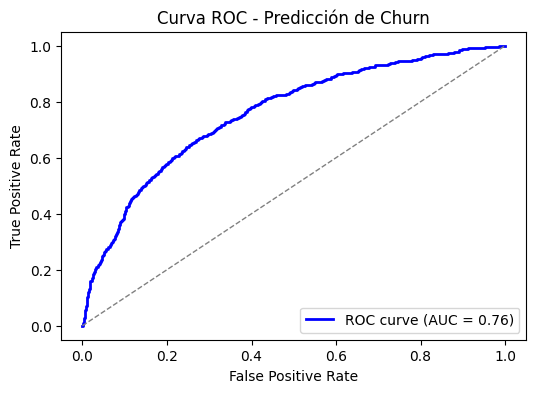

In [30]:
# Obtener los valores verdaderos y las probabilidades predichas
y_true = predictions.select("churn").toPandas()
y_score = predictions.select("probability").toPandas()["probability"].apply(lambda x: float(x[1]))

fpr, tpr, thresholds = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color="blue", lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Predicción de Churn")
plt.legend(loc="lower right")
plt.show()

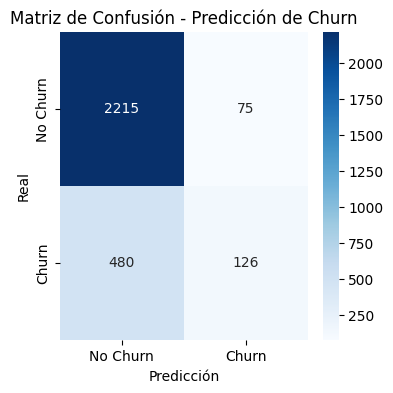

In [31]:
# Convertir las predicciones a pandas
y_true = predictions.select("churn").toPandas()
y_pred = predictions.select("prediction").toPandas()

# Calcular la matriz de confusión
cm = confusion_matrix(y_true, y_pred)

# Graficar la matriz de confusión
plt.figure(figsize=(4, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión - Predicción de Churn")
plt.show()

In [ ]:
# Calcular métricas
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1-score:  {f1:.3f}")

Accuracy:  0.808
Precision: 0.627
Recall:    0.208
F1-score:  0.312


#### Comentario sobre las métricas

Observamos que, aunque la exactitud (accuracy) es alta, la precisión, el recall y el F1-score son bajos. Esto suele indicar un problema de desbalanceo de clases, donde la clase "churn" (clientes que se van) es mucho menos frecuente que la clase "no churn". El modelo tiende a predecir la clase mayoritaria, lo que afecta negativamente la capacidad de detectar los casos de churn.

# 🔟 Balanceo de clases

A continuación, aplicaremos una técnica de balanceo para mejorar la detección de la clase minoritaria.

In [ ]:
# Calcular el peso inverso a la frecuencia de cada clase
# Esto sirve para que el modelo preste más atención a la clase minoritaria (churn=1)
total = df.count()
churn_count = df.filter(df.churn == 1).count()
no_churn_count = df.filter(df.churn == 0).count()

# El peso de cada clase es inversamente proporcional a su frecuencia
weight_churn = total / (2 * churn_count)
weight_no_churn = total / (2 * no_churn_count)

# Crear una nueva columna 'weight' con el peso correspondiente para cada fila
df_weighted = df.withColumn(
    "weight",
    when(df.churn == 1, weight_churn).otherwise(weight_no_churn)
)

In [36]:
# Dividir en train y test
train_w, test_w = df_weighted.randomSplit([0.7, 0.3], seed=42)

# Definir el modelo con weightCol
lr_weighted = LogisticRegression(featuresCol="features", labelCol="churn", weightCol="weight")
stages_w = indexers + encoders + [assembler, lr_weighted]
pipeline_w = Pipeline(stages=stages_w)

# Entrenar y evaluar
model_w = pipeline_w.fit(train_w)
predictions_w = model_w.transform(test_w)

# Calcular y mostrar métricas como antes
y_true_w = predictions_w.select("churn").toPandas()
y_pred_w = predictions_w.select("prediction").toPandas()

accuracy_w = accuracy_score(y_true_w, y_pred_w)
precision_w = precision_score(y_true_w, y_pred_w)
recall_w = recall_score(y_true_w, y_pred_w)
f1_w = f1_score(y_true_w, y_pred_w)

print(f"Accuracy (balanceado):  {accuracy_w:.3f}")
print(f"Precision (balanceado): {precision_w:.3f}")
print(f"Recall (balanceado):    {recall_w:.3f}")
print(f"F1-score (balanceado):  {f1_w:.3f}")

Accuracy (balanceado):  0.712
Precision (balanceado): 0.391
Recall (balanceado):    0.680
F1-score (balanceado):  0.497


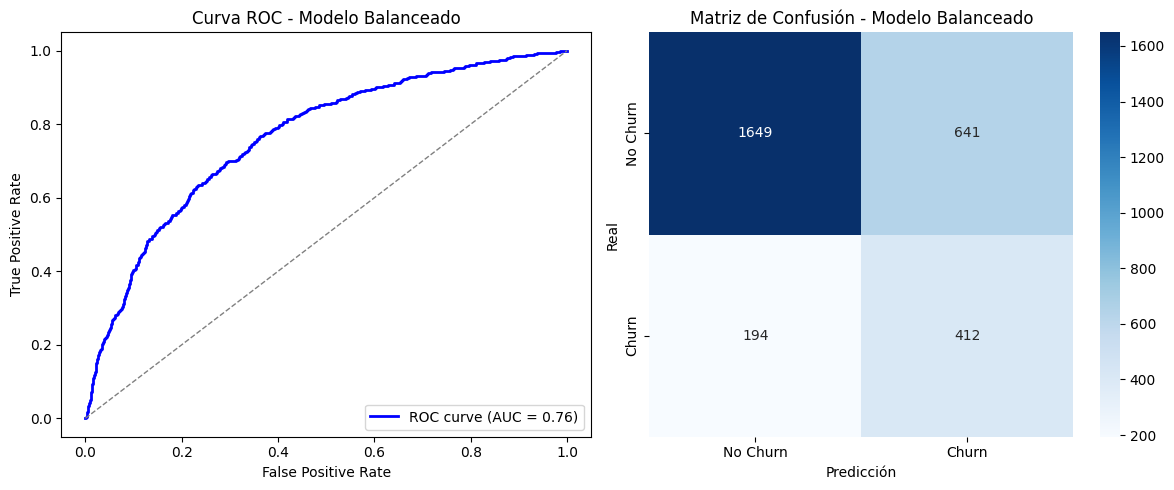

In [38]:
# Obtener los valores verdaderos y las probabilidades predichas del modelo balanceado
y_true_w = predictions_w.select("churn").toPandas()
y_score_w = predictions_w.select("probability").toPandas()["probability"].apply(lambda x: float(x[1]))
y_pred_w = predictions_w.select("prediction").toPandas()

# Curva ROC
fpr_w, tpr_w, _ = roc_curve(y_true_w, y_score_w)
roc_auc_w = auc(fpr_w, tpr_w)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(fpr_w, tpr_w, color="blue", lw=2, label=f"ROC curve (AUC = {roc_auc_w:.2f})")
plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Modelo Balanceado")
plt.legend(loc="lower right")

# Matriz de confusión
cm_w = confusion_matrix(y_true_w, y_pred_w)
plt.subplot(1, 2, 2)
sns.heatmap(cm_w, annot=True, fmt="d", cmap="Blues", xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión - Modelo Balanceado")

plt.tight_layout()
plt.show()

#### 📈 Conclusión tras el balanceo de clases

Luego de aplicar el balanceo de clases mediante el ajuste de pesos en la regresión logística, observamos una mejora significativa en la capacidad del modelo para detectar clientes que hacen churn:

- **Recall** aumentó considerablemente (de 0.208 a 0.680), lo que indica que el modelo ahora identifica correctamente a la mayoría de los clientes que realmente se van.
- **Precision** también mejoró, aunque sigue siendo moderada, lo que es habitual cuando se prioriza el recall en problemas desbalanceados.
- **F1-score** subió notablemente, reflejando un mejor equilibrio entre precisión y recall.
- **Accuracy** bajó levemente, pero esto es esperable y aceptable, ya que el objetivo principal es mejorar la detección de la clase minoritaria (churn), aunque implique cometer más errores sobre la clase mayoritaria.

**En resumen:**  
El balanceo de clases permitió que el modelo sea mucho más útil para el negocio, ya que ahora es capaz de identificar a la mayoría de los clientes en riesgo de fuga, aunque a costa de una mayor cantidad de falsos positivos. Este es un trade-off habitual y deseable en problemas donde la clase minoritaria es la más relevante para la toma de decisiones.

## 🔚 Cierre de la sesión Spark

Liberamos los recursos de Spark.

In [16]:
spark.stop()